# Monte Carlo Tree Search (MCTS) Implementation

In [1]:
from algorithms.mcts.MCTS import MCTS
from mdp.base_config import BaseConfig
from mdp.mdp_utils import display_value_function, display_policy, max_norm_error
from algorithms.value_iteration.value_iteration import ValueIteration
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

base_config = BaseConfig(seed=42)

## Cats vs Monsters MDP

### Generate Value Function using Value Iteration

In [2]:
from mdp.cats_v_monsters.cats_vs_monsters import CatsVMonstersMDP

optimal_mdp = CatsVMonstersMDP()
optimal_vi = ValueIteration(mdp=optimal_mdp)
optimal_rh = optimal_vi.run_value_iteration()
optimal_vf, optimal_policy = optimal_rh[len(optimal_rh)]
print("Optimal Value Function:")
display_value_function(optimal_mdp, optimal_vf)
print("Optimal Policy:")
display_policy(optimal_mdp, optimal_policy)

Optimal Value Function:
2.6638	2.9969	2.8117	3.6671	4.8497	
2.9713	3.5101	4.0819	4.8497	7.1648	
2.5936	0.0000	0.0000	0.0000	8.4687	
2.0992	1.0849	0.0000	8.6097	9.5269	
1.0849	4.9465	8.4687	9.5269	0.0000	
Optimal Policy:
→	↓	←	↓	↓	
→	→	→	→	↓	
↑	F	F	F	↓	
↑	←	F	↓	↓	
↑	→	→	→	G	


In [100]:
cvm = CatsVMonstersMDP(gamma=0.95)
mcts = MCTS(env=cvm, base_config=base_config, rollout_steps=20)
root_state = (3, 4)  # Starting state with 0 cats and 0 monsters
root, action = mcts.search(root_state=root_state, num_simulations=500)
print(f'From root state {root_state}, selected action: {action}, estimated value: {root.value}')

From root state (3, 4), selected action: left, estimated value: -188.35000000000116


In [101]:
for action, child in root.children.items():
    print(f'Action: {action}, Q-value: {child.value}, Visit Count: {child.visits}')

Action: right, Q-value: -170.95000000000127, Visit Count: 3
Action: left, Q-value: 10.0, Visit Count: 247
Action: down, Q-value: 10.0, Visit Count: 247
Action: up, Q-value: -37.39999999999989, Visit Count: 3


In [104]:
value_function, policy = mcts.generate_value_function_and_policy(num_simulations=5000)

Evaluating all states:   0%|          | 0/21 [00:00<?, ?it/s]

In [105]:
display_value_function(value_function=value_function, mdp=cvm)

-8.2131	-5.6993	-6.5411	-3.6991	-4.4491	
-7.8774	-9.9205	-1.3893	-1.5645	-0.9825	
-9.5551	0.0000	0.0000	0.0000	-1.1311	
-4.4064	-1.4377	0.0000	-0.2274	-0.0936	
-0.6183	-0.6895	-0.1721	-0.0201	0.0000	


In [106]:
display_policy(cvm, policy=policy)

←	↓	↑	←	↓	
→	↓	↓	↑	→	
↑	X	X	X	←	
→	→	X	→	←	
↑	→	↑	→	G	


## Generating for multiple c-values

In [45]:
c_vals = [0, 0.1, 0.5, 1.0, 3.0, 5.0]
c_vals_metadata = {}
for c in c_vals:
    print(f'\nExploration constant c = {c}')
    mcts = MCTS(env=cvm, base_config=base_config)
    value_function, policy = mcts.generate_value_function_and_policy(num_simulations=5000, c_value=c)
    max_norm = max_norm_error(optimal_vf, value_function)
    print(f'Max Norm Error compared to Optimal VI: {max_norm}')
    c_vals_metadata[c] = {
        'value_function': value_function,
        'policy': policy,
        'max_norm_error': max_norm
    }


Exploration constant c = 0


Evaluating all states:   0%|          | 0/21 [00:00<?, ?it/s]

Max Norm Error compared to Optimal VI: 31.723431876469093

Exploration constant c = 0.1


Evaluating all states:   0%|          | 0/21 [00:00<?, ?it/s]

Max Norm Error compared to Optimal VI: 37.402310591355274

Exploration constant c = 0.5


...

Max Norm Error compared to Optimal VI: 19.596540591355183

Exploration constant c = 3.0


Evaluating all states:   0%|          | 0/21 [00:00<?, ?it/s]

Max Norm Error compared to Optimal VI: 32.27214459423182

Exploration constant c = 5.0


Evaluating all states:   0%|          | 0/21 [00:00<?, ?it/s]

Max Norm Error compared to Optimal VI: 11.820923785867357


In [9]:
for c, metadata in c_vals_metadata.items():
    print(f'\nExploration constant c = {c}')
    print(f'Max Norm Error compared to Optimal VI: {metadata["max_norm_error"]}')
    print('Value Function:')
    display_value_function(value_function=metadata['value_function'], mdp=cvm)
    print('Policy:')
    display_policy(cvm, policy=metadata['policy'])


Exploration constant c = 0
Max Norm Error compared to Optimal VI: 31.00000533486945
Value Function:
-6.8430	-7.1216	-1.3698	-2.0556	-0.7956	
-28.0288	-13.2707	-8.8795	-0.7410	-3.1740	
-3.5514	0.0000	0.0000	0.0000	-0.1770	
-5.5313	-1.8990	0.0000	-1.0007	-0.0494	
-0.4222	-4.0018	-0.1090	-0.0679	0.0000	
Policy:
↑	→	→	↓	←	
↓	←	↑	→	↑	
↑	X	X	X	←	
↑	↑	X	↑	→	
↑	→	→	→	G	

Exploration constant c = 0.1
Max Norm Error compared to Optimal VI: 17.099534594231816
Value Function:
-10.8502	-5.1369	-6.9483	-3.2476	-4.2478	
-10.1604	-2.1056	-0.4422	-0.7166	-0.4414	
-14.5060	0.0000	0.0000	0.0000	-0.1675	
-2.5090	-1.1333	0.0000	-0.5161	-0.0377	
-0.8919	-0.2296	-0.9175	-0.2236	0.0000	
Policy:
←	←	↑	←	↑	
←	→	→	↓	↓	
↓	X	X	X	↓	
↓	↓	X	→	↓	
→	→	→	→	G	

Exploration constant c = 0.5
Max Norm Error compared to Optimal VI: 33.21585059135528
Value Function:
-30.5521	-13.0459	-2.2106	-8.2091	-2.5488	
-1.9292	-10.6751	-2.2178	-0.5802	-0.8491	
-2.2397	0.0000	0.0000	0.0000	-0.8506	
-7.6823	-1.1630	0.0000	-0.7144	-0.6776

In [46]:
valid_states = cvm.get_valid_state_space()
diagnostics_data = mcts.mcts_diagnostics_multiple(valid_states, num_simulations=5000, c_value=10)

MCTS Diagnostics Multiple States:   0%|          | 0/21 [00:00<?, ?it/s]

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

...

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

MCTS Diagnostics:   0%|          | 0/5000 [00:00<?, ?it/s]

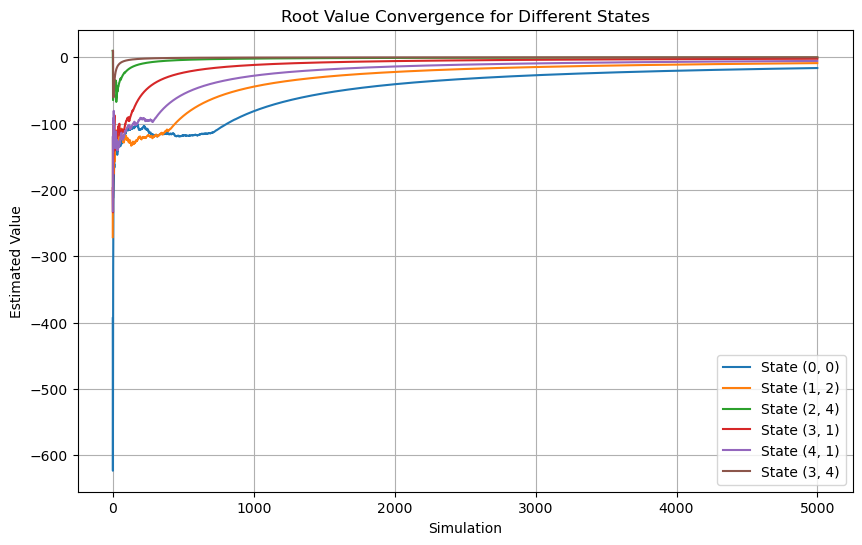

In [47]:
plt.figure(figsize=(10, 6))
selected_states = [(0,0), (1,2), (2,4), (3,1), (4,1), (3,4)]
for root_state in selected_states:
    (root_value_history, _, _) = diagnostics_data[root_state]
    plt.plot(root_value_history, label=f"State {root_state}")
plt.title(f"Root Value Convergence for Different States")
plt.xlabel("Simulation")
plt.ylabel("Estimated Value")
plt.grid(True)
plt.legend()
plt.show()

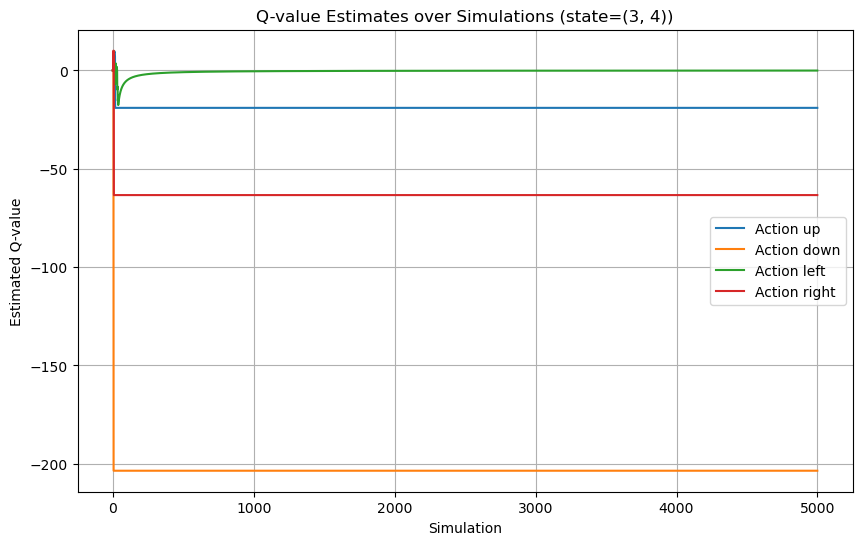

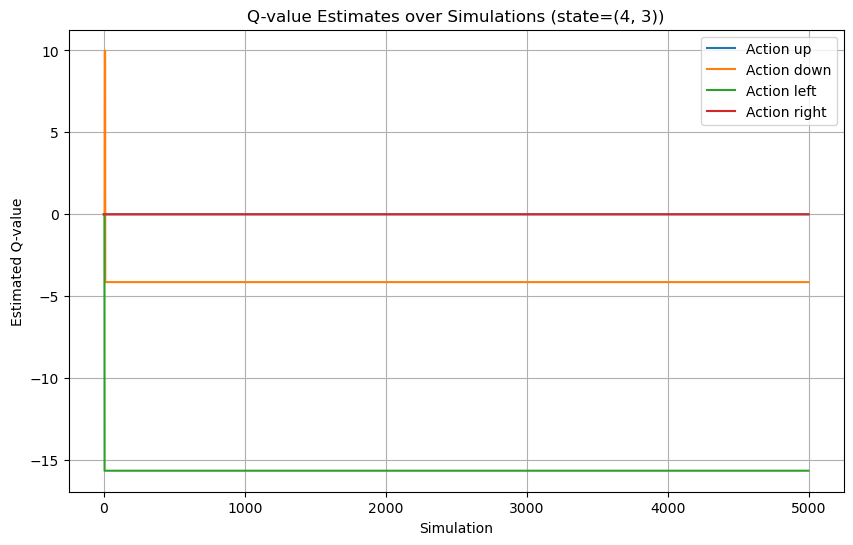

In [29]:
# --- Plot Q-value Estimates ---
def plot_q_value_estimates(diagnostics_data, state):
    plt.figure(figsize=(10, 6))
    for action, q_value_history in diagnostics_data[state][1].items():
        plt.plot(q_value_history, label=f"Action {action}")
    plt.title(f"Q-value Estimates over Simulations (state={state})")
    plt.xlabel("Simulation")
    plt.ylabel("Estimated Q-value")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_q_value_estimates(diagnostics_data, state=(3,4))
plot_q_value_estimates(diagnostics_data, state=(4,3))

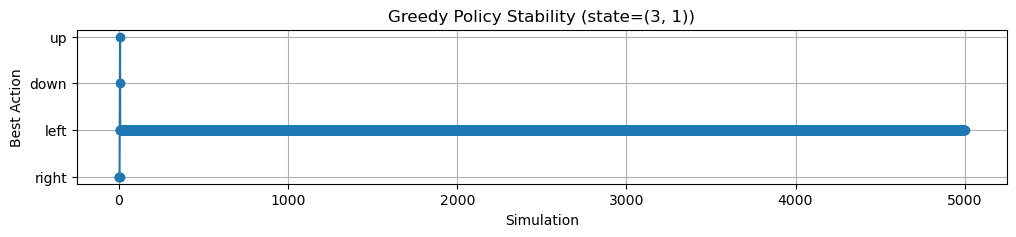

In [22]:
plt.figure(figsize=(12, 2))
root_state = (3,1)
_, _, policy_history = diagnostics_data[root_state]
plt.plot(policy_history, marker='o')
plt.title(f"Greedy Policy Stability (state={root_state})")
plt.xlabel("Simulation")
plt.ylabel("Best Action")
plt.grid(True)
plt.show()